# Настройка окружения ML Edu

## 1. Создание виртуального окружения
```bash
cd E:\ML_edu
python -m venv .venv
2. Активация

.venv\Scripts\activate
После активации в терминале появится (.venv) в начале строки.

3. Установка библиотек

pip install pandas numpy matplotlib seaborn scikit-learn ipykernel
4. Регистрация ядра для Jupyter

python -m ipykernel install --user --name ml_edu --display-name "ML Edu (Python 3.13)"
5. Выбор ядра в VS Code
Открой блокнот adidas.ipynb
Нажми на ядро вверху справа
Выбери ML Edu (Python 3.13)
Нажми Restart и запусти первую ячейку




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


pandas — это главная библиотека для работы с таблицами в Python. pd — просто короткое прозвище, чтобы не писать pandas. каждый раз. numpy — математика и массивы, pandas использует его внутри себя.

## Что такое DataFrame

`DataFrame` — это главный объект библиотеки pandas. Думай о нём как об умной
таблице: строки, колонки, индексы. Всё что можно делать в Excel — можно делать
с DataFrame, только быстрее и на миллионах строк.
```python
df = pd.read_csv("Adidas_Global.csv", low_memory=False)
```

После этой строки переменная `df` содержит всю таблицу в памяти.
`df` — просто имя переменной, можно назвать хоть `таблица`, но `df` — общепринятое.

---

### Как устроен DataFrame
```
         product_name   country_code   price_local   rating
0        Stan Smith     US             80.0          4.8
1        Ultraboost     DE             180.0         4.9
2        Gazelle        FR             100.0         NaN
...
44887    Campus         MX             1799.0        4.7
```

- **Строки** — каждая запись (в нашем случае один SKU)
- **Колонки** — признаки (поля данных)
- **Индекс** — номер строки слева (0, 1, 2...), создаётся автоматически

---

### Основные операции

**Размер таблицы:**
```python
df.shape          # (44888, 35) — кортеж (строки, колонки)
df.shape[0]       # 44888 — только строки
df.shape[1]       # 35 — только колонки
len(df)           # 44888 — тоже количество строк
```

**Просмотр данных:**
```python
df.head()         # первые 5 строк
df.head(10)       # первые 10 строк
df.tail()         # последние 5 строк
df.sample(5)      # 5 случайных строк
```

**Одна колонка → Series:**
```python
df['price_local']            # вся колонка как список значений
df['price_local'].head()     # первые 5 значений колонки
```

**Несколько колонок → новый DataFrame:**
```python
df[['product_name', 'price_local', 'country_code']]
```

---

### Фильтрация строк

Самый важный приём — квадратные скобки с условием:
```python
# Только товары из США
df[df['country_code'] == 'US']

# Только товары дороже 100 (в локальной валюте)
df[df['price_local'] > 100]

# Два условия сразу: & означает "и", | означает "или"
df[(df['country_code'] == 'US') & (df['price_local'] > 100)]

# Товары со скидкой
df[df['discount_pct'] > 0]

# Строки где рейтинг не пустой
df[df['rating'].notna()]
```

---

### Агрегация — считаем итоги
```python
df['price_local'].mean()     # среднее
df['price_local'].median()   # медиана
df['price_local'].max()      # максимум
df['country_code'].value_counts()   # сколько строк по каждой стране
```

---

### Главное правило

`df` сам по себе не меняется пока ты явно не присвоишь результат обратно.
```python
df[df['country_code'] == 'US']        # просмотр — df не изменился
df_us = df[df['country_code'] == 'US'] # сохранили в новую переменную
```

In [2]:
df = pd.read_csv("Adidas_Global.csv", low_memory=False)

print(f"Строк: {df.shape[0]:,}")
print(f"Колонок: {df.shape[1]}")
df.head()

Строк: 44,888
Колонок: 35


,snapshot_date,country_code,product_name,model_number,currency,price_local,sale_price_local,gender_segment,size_label,category,...,rating_count,badge_texts,product_url,canonical_url,image_url,best_for_ids,seen_market_count,seen_markets,market_record_source,size_record_source
0,2026-03-09,BR,AGASALHO COM CAPUZ BIG LOGO,KSG46,BRL,429.99,549.99,M,2GG,Lifestyle,...,-99.0,NaN,https://www.adidas.com.br/agasalho-com-capuz-b...,https://www.adidas.com.br/agasalho-com-capuz-b...,"https://assets.adidas.com/images/w_600,f_auto,...",[],1,BR,api,api_exact
1,2026-03-09,BR,AGASALHO COM CAPUZ BIG LOGO,KSG46,BRL,429.99,549.99,M,2GG/T,Lifestyle,...,-99.0,NaN,https://www.adidas.com.br/agasalho-com-capuz-b...,https://www.adidas.com.br/agasalho-com-capuz-b...,"https://assets.adidas.com/images/w_600,f_auto,...",[],1,BR,api,api_exact
2,2026-03-09,BR,AGASALHO COM CAPUZ BIG LOGO,KSG46,BRL,429.99,549.99,M,2XT2,Lifestyle,...,-99.0,NaN,https://www.adidas.com.br/agasalho-com-capuz-b...,https://www.adidas.com.br/agasalho-com-capuz-b...,"https://assets.adidas.com/images/w_600,f_auto,...",[],1,BR,api,api_exact
3,2026-03-09,BR,AGASALHO COM CAPUZ BIG LOGO,KSG46,BRL,429.99,549.99,M,2XT3,Lifestyle,...,-99.0,NaN,https://www.adidas.com.br/agasalho-com-capuz-b...,https://www.adidas.com.br/agasalho-com-capuz-b...,"https://assets.adidas.com/images/w_600,f_auto,...",[],1,BR,api,api_exact
4,2026-03-09,BR,AGASALHO COM CAPUZ BIG LOGO,KSG46,BRL,429.99,549.99,M,3GG,Lifestyle,...,-99.0,NaN,https://www.adidas.com.br/agasalho-com-capuz-b...,https://www.adidas.com.br/agasalho-com-capuz-b...,"https://assets.adidas.com/images/w_600,f_auto,...",[],1,BR,api,api_exact


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44888 entries, 0 to 44887
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   snapshot_date         44888 non-null  str    
 1   country_code          44888 non-null  str    
 2   product_name          44888 non-null  str    
 3   model_number          44537 non-null  str    
 4   currency              44888 non-null  str    
 5   price_local           44888 non-null  float64
 6   sale_price_local      25970 non-null  float64
 7   gender_segment        44522 non-null  str    
 8   size_label            44888 non-null  str    
 9   category              44371 non-null  str    
 10  subcategory           29785 non-null  str    
 11  product_id            44888 non-null  str    
 12  sku                   43514 non-null  str    
 13  base_model_number     42931 non-null  str    
 14  brand_name            44888 non-null  str    
 15  color_name            4541 non

In [4]:
df.describe()

,price_local,sale_price_local,size_count,available_size_count,discount_pct,rating,rating_count,seen_market_count
count,44888.000000,25970.000000,44888.000000,42471.000000,30874.000000,17421.000000,25747.000000,44888.000000
mean,13655.551401,14437.644213,17.059481,10.057639,5.159195,4.675154,339.444052,1.889458
std,43890.047585,42114.237692,8.694806,5.940405,13.584695,0.367331,1919.065610,1.354160
min,6.000000,6.000000,1.000000,1.000000,-45.000000,1.000000,-99.000000,1.000000
25%,100.000000,199.990000,12.000000,6.000000,0.000000,4.628600,-99.000000,1.000000
50%,599.990000,1799.000000,17.000000,8.000000,0.000000,4.739200,13.000000,1.000000
75%,9999.000000,10999.000000,22.000000,15.000000,0.000000,4.863700,97.000000,3.000000
max,599000.000000,599000.000000,73.000000,33.000000,60.000000,5.000000,19686.000000,8.000000


## Первичная статистика данных (df.describe())

Метод `describe()` возвращает сводную статистику по всем числовым колонкам датафрейма.
Используется для первичной оценки распределения данных и обнаружения аномалий.

**Ключевые наблюдения:**

- `price_local`: медиана (50%) = 599.99, среднее = 13,655 — сильный разброс объясняется
  тем, что цены указаны в локальных валютах (JPY, KRW, INR), что делает прямое
  сравнение некорректным без конвертации в единую валюту.

- `sale_price_local`: count = 25,970 из 44,888 — примерно 42% строк не имеют
  цены со скидкой, что соответствует товарам без активной акции.

- `discount_pct`: min = -45 — отрицательные значения скидки являются аномалией
  и подлежат анализу на этапе очистки данных.

- `rating`: count = 17,421 — рейтинг присутствует менее чем у 39% записей,
  что ограничивает применимость этой переменной как признака для модели.

- `rating_count`: min = -99 — отрицательное количество отзывов является
  техническим артефактом и должно быть обработано при очистке.

**Вывод:** данные содержат аномалии в полях `discount_pct` и `rating_count`,
требующие обработки перед построением моделей.

In [5]:
df.isnull().sum()


snapshot_date               0
country_code                0
product_name                0
model_number              351
currency                    0
price_local                 0
sale_price_local        18918
gender_segment            366
size_label                  0
category                  517
subcategory             15103
product_id                  0
sku                      1374
base_model_number        1957
brand_name                  0
color_name              40347
size_count                  0
size_labels                 0
available_size_count     2417
availability             1099
availability_units       1374
availability_status      1099
in_stock                 2417
discount_pct            14014
rating                  27467
rating_count            19141
badge_texts             33810
product_url                28
canonical_url              13
image_url                 366
best_for_ids                0
seen_market_count           0
seen_markets                0
market_rec

## Анализ пропущенных значений (df.isnull().sum())

Метод `isnull().sum()` возвращает количество значений NaN по каждой колонке.
Понимание структуры пропусков критично перед любой аналитикой и машинным обучением.

**Колонки без пропусков (качественные данные):**
`snapshot_date`, `country_code`, `product_name`, `price_local`, `brand_name`,
`size_label`, `size_count`, `size_labels` — могут использоваться напрямую.

**Значительные пропуски (требуют решения):**

| Колонка            | Пропусков | % от 44,888 | Интерпретация |
|--------------------|-----------|-------|---------------------------------------|
| `color_name`       | 40,347    | 89.9% | Колонка практически пуста — исключить |
| `rating`           | 27,467    | 61.2% | Рейтинг есть у меньшинства товаров    |
| `sale_price_local` | 18,918    | 42.1%       | NaN = нет скидки, не ошибка           |
| `subcategory`      | 15,103    | 33.6%       | Заполнена непоследовательно           |
| `discount_pct`     | 14,014    | 31.2%       | NaN = скидки нет                      |

**Важное замечание:** не все пропуски являются ошибками. Например, NaN в
`sale_price_local` означает отсутствие скидки — это семантически значимо.
Такие пропуски заменяются не средним, а логическим значением (например, 0).

**Вывод:** перед построением модели необходима стратегия обработки пропусков
для каждой колонки в зависимости от её смысла в предметной области.

## Инструменты разведки данных (EDA Quick Tools)

Набор методов для быстрого понимания структуры и качества датафрейма.

In [6]:
# Процент пропусков — нагляднее чем просто count
df.isnull().sum() / len(df) * 100

snapshot_date            0.000000
country_code             0.000000
product_name             0.000000
model_number             0.781946
currency                 0.000000
price_local              0.000000
sale_price_local        42.144894
gender_segment           0.815363
size_label               0.000000
category                 1.151755
subcategory             33.645963
product_id               0.000000
sku                      3.060952
base_model_number        4.359740
brand_name               0.000000
color_name              89.883711
size_count               0.000000
size_labels              0.000000
available_size_count     5.384513
availability             2.448316
availability_units       3.060952
availability_status      2.448316
in_stock                 5.384513
discount_pct            31.219925
rating                  61.190073
rating_count            42.641686
badge_texts             75.320798
product_url              0.062377
canonical_url            0.028961
image_url     

In [7]:
# Процент пропусков — отсортировано по убыванию, только значимые (> 1%)
missing = df.isnull().sum() / len(df) * 100
missing = missing[missing > 1].sort_values(ascending=False)
missing

color_name              89.883711
badge_texts             75.320798
rating                  61.190073
rating_count            42.641686
sale_price_local        42.144894
subcategory             33.645963
discount_pct            31.219925
in_stock                 5.384513
available_size_count     5.384513
base_model_number        4.359740
sku                      3.060952
availability_units       3.060952
availability_status      2.448316
availability             2.448316
category                 1.151755
dtype: float64

## Фильтрация и сортировка Series
```python
missing = df.isnull().sum() / len(df) * 100
missing = missing[missing > 1].sort_values(ascending=False)
missing
```

- `df.isnull().sum() / len(df) * 100` — считает процент пропусков по каждой колонке
- `missing[missing > 1]` — фильтрация: оставляет только колонки где пропусков больше 1%.
  Квадратные скобки с условием внутри — один из главных приёмов pandas,
  работает везде: с колонками, строками, любыми Series
- Порог 1% — практическое правило: меньше 1% пропусков не влияют на модель
  и не стоят внимания
- `.sort_values(ascending=False)` — сортировка по убыванию.
  `ascending=False` — от большего к меньшему, `True` — наоборот

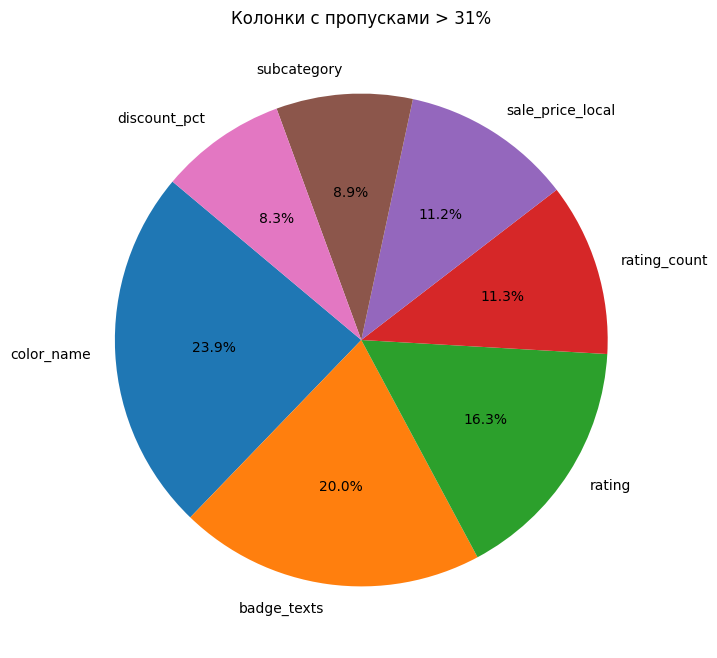

In [8]:


# Оставляем только колонки с пропусками больше 31%
missing = df.isnull().sum() / len(df) * 100
missing = missing[missing > 31].sort_values(ascending=False)

# Строим пайчарт
plt.figure(figsize=(8, 8))
plt.pie(
    missing,
    labels=missing.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Колонки с пропусками > 31%')
plt.show()

## Анализ результата: колонки с критическими пропусками

Диаграмма показывает распределение пропусков среди колонок с порогом > 31%.
Всего таких колонок 7 — это наши главные проблемы перед очисткой данных.

| Колонка | % пропусков | Решение |
|---|---|---|
| `color_name` | 89.9% | Удалить — 90% пустых, бесполезна как признак |
| `badge_texts` | 75.3% | Удалить — маркетинговые теги, нерелевантны |
| `rating` | 61.2% | Оставить, заполнить NaN → 0 или медианой |
| `rating_count` | 42.6% | Оставить, заполнить NaN → 0 |
| `sale_price_local` | 42.1% | Оставить — NaN означает "скидки нет" → заполнить 0 |
| `subcategory` | 33.6% | Оставить — заполнить значением из `category` |
| `discount_pct` | 31.2% | Оставить — NaN означает "скидки нет" → заполнить 0 |

**Правило выбора стратегии:**
- Пропусков > 70% → удалить колонку
- Пропуски имеют смысл (нет скидки, нет отзывов) → заполнить 0
- Пропуски случайные → заполнить медианой или модой

In [9]:
# Типы данных каждой колонки — быстрее чем df.info()
df.dtypes

snapshot_date               str
country_code                str
product_name                str
model_number                str
currency                    str
price_local             float64
sale_price_local        float64
gender_segment              str
size_label                  str
category                    str
subcategory                 str
product_id                  str
sku                         str
base_model_number           str
brand_name                  str
color_name                  str
size_count                int64
size_labels                 str
available_size_count    float64
availability                str
availability_units          str
availability_status         str
in_stock                 object
discount_pct            float64
rating                  float64
rating_count            float64
badge_texts                 str
product_url                 str
canonical_url               str
image_url                   str
best_for_ids                str
seen_mar

## Типы данных колонок (df.dtypes)

Тип данных определяет как pandas хранит значения в памяти и какие операции
доступны над колонкой. Неправильный тип — частая причина ошибок в моделях.

### Три типа которые мы видим

| Тип | Что означает | Примеры в нашем датасете |
|---|---|---|
| `str` (object) | Текст или смешанные данные | `product_name`, `country_code`, `category` |
| `float64` | Дробное число (64-битное) | `price_local`, `rating`, `discount_pct` |
| `int64` | Целое число (64-битное) | `size_count`, `seen_market_count` |

### Что требует внимания

**`snapshot_date` → тип `str`**
Дата хранится как текст — pandas не понимает что это дата.
Для любых операций с датами (сортировка, разница дней) нужно конвертировать:
`pd.to_datetime(df['snapshot_date'])`

**`in_stock` → тип `object`**
Должен быть булевым (`True/False`), но хранится как object — значит
в колонке смешаны разные форматы (строки "True", числа 1/0, NaN).
Требует очистки перед использованием как признака.

**`available_size_count` → тип `float64`**
Количество размеров не может быть дробным — это целое число.
Значит в колонке есть NaN (pandas автоматически делает int → float при наличии NaN).
После заполнения пропусков можно конвертировать в `int64`.

### Правило для ML моделей

Большинство алгоритмов принимают только числа.
Все колонки типа `str` перед подачей в модель нужно превратить в числа —
это называется **кодирование категориальных признаков** (Урок 4).

In [10]:
# Уникальные значения в каждой колонке — ищем категориальные
df.nunique()


snapshot_date               2
country_code               10
product_name             2051
model_number             1492
currency                    9
price_local               431
sale_price_local          392
gender_segment              9
size_label                962
category                   53
subcategory               162
product_id               2757
sku                     33523
base_model_number        1600
brand_name                  1
color_name                131
size_count                 36
size_labels               536
available_size_count       28
availability                5
availability_units         17
availability_status         6
in_stock                    1
discount_pct               96
rating                    493
rating_count              262
badge_texts                57
product_url              3552
canonical_url            2752
image_url                2652
best_for_ids              171
seen_market_count           8
seen_markets              113
market_rec

## Анализ уникальных значений (df.nunique())

`nunique()` показывает сколько **различных значений** содержит каждая колонка.
Это главный инструмент для понимания природы данных — категориальные они или числовые.

---

### Три категории колонок по количеству уникальных значений

**Константы и псевдоконстанты (1–2 уникальных значения)**

| Колонка | Уникальных | Вывод |
|---|---|---|
| `brand_name` | 1 | Всегда "adidas" — бесполезна как признак, удалить |
| `in_stock` | 1 | Одно значение — колонка не несёт информации |
| `market_record_source` | 1 | То же самое |
| `snapshot_date` | 2 | Только 2 даты съёмки данных |
| `size_record_source` | 2 | Технический атрибут |

Правило: колонка с 1 уникальным значением — **нулевая дисперсия**.
Модель не может ничему научиться на такой колонке, она только занимает память.

---

**Категориальные признаки (малое число уникальных значений)**

| Колонка | Уникальных | Вывод |
|---|---|---|
| `country_code` | 10 | Идеальный категориальный признак — ровно 10 стран |
| `currency` | 9 | Соответствует странам |
| `gender_segment` | 9 | Пол/возраст — категория для модели |
| `availability` | 5 | Статус доступности |
| `availability_status` | 6 | Похожа на `availability` — возможно дубль |
| `category` | 53 | Много, но это потому что названия на 6 языках → нормализовать |
| `seen_market_count` | 8 | Сколько рынков видели товар |

Эти колонки **кодируем** перед подачей в модель (Урок 4).

---

**Высококардинальные признаки (много уникальных значений)**

| Колонка | Уникальных | Вывод |
|---|---|---|
| `sku` | 33,523 | Уникальный ID размера — не признак, идентификатор |
| `product_id` | 2,757 | ID продукта — идентификатор |
| `product_name` | 2,051 | Текст — для NLP или удалить |
| `model_number` | 1,492 | Ключ дедупликации |
| `size_label` | 962 | Размеры — слишком много вариантов |
| `subcategory` | 162 | Много + 34% пропусков → осторожно |

Высококардинальные строковые колонки в модель **не подают напрямую** —
либо преобразуют, либо удаляют.

---

### Интересные находки

**`category` = 53 уникальных значения** — но реальных категорий всего ~10.
Остальные 43 — это те же категории на португальском, немецком, японском, китайском.
Это одна из главных задач очистки: привести к единому языку.

**`availability` (5) vs `availability_status` (6)** — две очень похожие колонки.
Скорее всего дублируют информацию. Проверим корреляцию на уроке очистки.

**`discount_pct` = 96 уникальных значений** — это числовой признак
с реальным разнообразием, хорошо подойдёт для модели после очистки аномалий.

---

### Правило для выбора признаков модели

| Уникальных значений | Тип | Действие |
|---|---|---|
| 1 | Константа | Удалить |
| 2–50 | Категориальный | Закодировать (get_dummies) |
| 50–1000 | Числовой или текст | Анализировать отдельно |
| > 1000 | Идентификатор | Не использовать как признак |

In [11]:
# Что за уникальные значения в конкретной колонке
df['country_code'].value_counts()

country_code
IN    6643
JP    6037
US    5746
DE    5004
MX    4992
BR    4680
GB    4283
FR    4061
KR    2538
CN     904
Name: count, dtype: int64

## Распределение по странам (df['country_code'].value_counts())

`value_counts()` — считает сколько строк содержит каждое уникальное значение,
и сразу сортирует по убыванию. Один из самых часто используемых методов в EDA.

---

### Что мы видим

| Страна | Строк (SKU) | Доля от 44,888 |
|---|---|---|
| IN (Индия) | 6,643 | 14.8% |
| JP (Япония) | 6,037 | 13.5% |
| US (США) | 5,746 | 12.8% |
| DE (Германия) | 5,004 | 11.1% |
| MX (Мексика) | 4,992 | 11.1% |
| BR (Бразилия) | 4,680 | 10.4% |
| GB (Великобритания) | 4,283 | 9.5% |
| FR (Франция) | 4,061 | 9.1% |
| KR (Южная Корея) | 2,538 | 5.7% |
| CN (Китай) | 904 | 2.0% |

---

### Ключевые наблюдения

**Индия и Япония — крупнейшие каталоги** (14.8% и 13.5%).
Это строки, не модели — много размеров на каждый товар.
Вспоминаем: чтобы сравнивать страны честно, нужно дедуплицировать
по `model_number`, а не считать SKU.

**Китай (CN) сильно выбивается — всего 904 строки (2%).**
В 7 раз меньше Индии. Причина: закрытая экосистема (WeChat, Tmall),
Adidas ведёт там отдельный каталог с другой структурой.
Это называется **selection bias** — выборка нерепрезентативна для CN.

**Корея (KR) — 5.7%**, тоже заметно меньше остальных.
Вероятно, меньший ассортимент на этом рынке.

---

### Как применять value_counts() дальше
```python
# Показать в процентах вместо абсолютных чисел
df['country_code'].value_counts(normalize=True) * 100

# Применить к любой другой колонке — например к категориям
df['category'].value_counts().head(10)

# Или к полу
df['gender_segment'].value_counts()
```

---

### Вывод для модели

`country_code` — отличный **категориальный признак**:
- всего 10 значений
- нет пропусков
- явная разница в распределении между странами

Именно такие колонки модели любят больше всего.

In [17]:
# Сколько строк дублируются полностью
df.duplicated().sum()

np.int64(0)

## Проверка дубликатов (df.duplicated().sum())

`duplicated()` проверяет каждую строку — встречалась ли она раньше в датафрейме.
`sum()` суммирует все найденные дубли (True = 1, False = 0).

**Результат: 0** — полных дубликатов нет. Это хорошая новость.

Но важно понять почему их нет. Каждая строка у нас — это **SKU**:
уникальная комбинация товара + страны + размера. Разные размеры одного
товара — это разные строки, поэтому полных совпадений быть не может.

Это значит: `duplicated()` нам здесь не поможет, но проблема дублей
всё равно существует — просто на другом уровне.
```python
# Полных дубликатов нет
df.duplicated().sum()  # → 0

# Но один товар встречается много раз — по одному на каждый размер
# Чтобы работать с товарами (не размерами) — нужна дедупликация
df.duplicated(subset=['country_code', 'model_number']).sum()
```

Вторая строка покажет сколько строк являются "лишними копиями" одного товара
в одной стране. Это и есть наша реальная задача дедупликации — Урок 2.

**Вывод:** `duplicated()` без аргументов проверяет полное совпадение всех
35 колонок. С аргументом `subset` — только выбранных. Всегда думай
на каком уровне ищешь дубли: строк, товаров или моделей.

In [30]:
df.duplicated(subset=['country_code', 'model_number']).sum()

np.int64(42898)

## Дубликаты на уровне товаров (df.duplicated(subset=...).sum())
```python
df.duplicated(subset=['country_code', 'model_number']).sum()  # → 42,898
```

**42,898 из 44,888 строк** — это "повторные" строки если смотреть
на уровне товара внутри страны. То есть реально уникальных
комбинаций "страна + модель" всего:

**44,888 − 42,898 = 1,990 уникальных товаров**

---

### Почему так много "дублей"?

Вспоминаем структуру датасета: каждая строка = один размер одного товара.
Кроссовок Ultraboost в США существует в 12 размерах → 12 строк,
но это один товар с одной ценой.
```
model_number   country_code   size_label   price_local
NRW94          US             7            150.0        ← строка 1
NRW94          US             8            150.0        ← строка 2  (дубль по нашему subset)
NRW94          US             9            150.0        ← строка 3  (дубль)
NRW94          US             10           150.0        ← строка 4  (дубль)
```

---

### Два датафрейма — два уровня анализа

Теперь понятно что нам нужны **два объекта** для разных задач:
```python
# df — исходный, уровень размеров (44,888 строк)
# нужен когда анализируем наличие размеров, остатки

# df_products — уровень товаров (1,990 строк)
# нужен для всего остального: цены, рейтинги, категории, ML-модели
df_products = df.drop_duplicates(subset=['country_code', 'model_number']).copy()

print(f"Уровень SKU:     {len(df):,} строк")
print(f"Уровень товаров: {len(df_products):,} строк")
```

`.copy()` в конце — важная деталь. Без него pandas создаёт "вид" на
оригинальный датафрейм, и при попытке изменить `df_products` выдаст
предупреждение `SettingWithCopyWarning`. С `.copy()` — создаётся
полностью независимая копия.

---

### Вывод

Это и есть первый реальный шаг **Урока 2 — очистки данных**.
Все дальнейшие анализы цен, рейтингов и построение модели —
только на `df_products`.

In [25]:
# Случайные 5 строк — иногда лучше head(), показывает разнообразие
df.sample(5)

,snapshot_date,country_code,product_name,model_number,currency,price_local,sale_price_local,gender_segment,size_label,category,...,rating_count,badge_texts,product_url,canonical_url,image_url,best_for_ids,seen_market_count,seen_markets,market_record_source,size_record_source
44679,2026-02-28,US,Y-3 PINSTRIPE REFINED WOOL WIDE LEG PANTS,Q2776,USD,450.0,NaN,M,XS,Lifestyle,...,-99.0,Recycled Polyester,https://www.adidas.com/us/y-3-pinstripe-refine...,https://www.adidas.com/us/y-3-pinstripe-refine...,"https://assets.adidas.com/images/w_600,f_auto,...",[],1,US,api,api_exact
34219,2026-03-09,MX,CALZADO DE RUNNING SUPERNOVA RISE 3,OSQ94,MXN,3399.0,NaN,M,MX 11.5,Running,...,NaN,Envío Gratis,https://www.adidas.mx/calzado-de-running-super...,https://www.adidas.co.in/supernova-rise-3-runn...,"https://assets.adidas.com/images/w_600,f_auto,...","[""Walking""]",2,IN | MX,api,api_exact
23435,2026-03-09,IN,SAMBA OG SHOES,OOK61,INR,10999.0,10999.0,W,11,Lifestyle,...,72.0,NaN,https://www.adidas.co.in/samba-og-shoes/IH9127...,https://www.adidas.co.in/samba-og-shoes/IH9127...,"https://assets.adidas.com/images/w_600,f_auto,...",[],2,IN | JP,api,api_exact
38874,2026-03-09,MX,Tenis Dropset Base,NSW99,MXN,1399.0,1399.0,M,MX 6.5,Training,...,134.0,NaN,https://www.adidas.mx/tenis-dropset-base/JR930...,https://www.adidas.mx/tenis-dropset-base/JR930...,"https://assets.adidas.com/images/w_600,f_auto,...","[""Overpronation"",""Hybrid Training""]",1,MX,api,api_exact
18848,2026-03-09,GB,adidas x entire studios Optime Training Bra Me...,SF314,GBP,65.0,65.0,W,XL,Gym & Training,...,-99.0,Member Exclusive,https://www.adidas.co.uk/adidas-x-entire-studi...,https://www.adidas.de/adidas-x-entire-studios-...,"https://assets.adidas.com/images/w_600,f_auto,...","[""Staying Cool""]",3,DE | FR | GB,api,api_exact


## Случайная выборка (df.sample(5))

`sample(n)` возвращает n случайных строк из датафрейма. При каждом запуске
результат разный — именно поэтому он ценнее чем `head()`, который всегда
показывает одни и те же первые строки.

---

### Что мы видим в этих 5 строках

**Индексы слева (44679, 34219, 23435...)** — это оригинальные номера строк
из датафрейма. Они не сбрасываются при `sample()`, поэтому видно что строки
действительно случайные из разных мест таблицы.

**Разнообразие стран:** US, MX, IN, MX, GB — выборка захватила 4 разные страны.
Хороший знак — данные равномерно перемешаны, нет группировки по стране.

**`sale_price_local` = NaN у трёх строк** — подтверждает что большинство
товаров продаются без скидки. Это не ошибка, это норма для этих данных.

**`rating_count` = -99.0** — снова встречаем аномалию которую мы уже видели
в `describe()`. Значение -99 — это технический маркер "нет данных",
который кто-то использовал вместо NaN. Будем исправлять в Уроке 2.

**`badge_texts`** — у одной строки "Recycled Polyester", у другой "Envío Gratis"
(бесплатная доставка по-испански), у третьей "Member Exclusive". Это
маркетинговые теги — разные языки, разный смысл. 75% пропусков мы уже видели.
Колонка кандидат на удаление.

**`price_local` vs `sale_price_local`:**
```
SAMBA OG SHOES (IN):  price=10999, sale_price=10999  → скидки нет (одинаковые)
Tenis Dropset (MX):   price=1399,  sale_price=1399   → скидки нет
```
Интересно — когда скидки нет, иногда `sale_price_local` = `price_local`,
а иногда = NaN. Это непоследовательность в данных, тоже задача для очистки.

---

### Зачем запускать sample() несколько раз
```python
df.sample(5)   # каждый раз новые строки
df.sample(5, random_state=42)  # фиксированный результат — для воспроизводимости
```

`random_state=42` — "зерно" генератора случайных чисел. С ним `sample()`
всегда вернёт одни и те же строки — удобно когда хочешь показать
конкретный пример коллеге или зафиксировать в учебнике.

---

### Вывод

Пять случайных строк подтвердили три проблемы которые мы уже нашли:
- `-99` как замена NaN в `rating_count`
- Непоследовательное заполнение `sale_price_local`
- Многоязычность в текстовых колонках

Это называется **data quality check** — и `sample()` один из лучших
инструментов для него именно потому что показывает реальные данные,
а не "причёсанные" первые строки.

In [26]:
# Отфильтровать только строки где есть хоть один пропуск
df[df.isnull().any(axis=1)]

,snapshot_date,country_code,product_name,model_number,currency,price_local,sale_price_local,gender_segment,size_label,category,...,rating_count,badge_texts,product_url,canonical_url,image_url,best_for_ids,seen_market_count,seen_markets,market_record_source,size_record_source
0,2026-03-09,BR,AGASALHO COM CAPUZ BIG LOGO,KSG46,BRL,429.99,549.99,M,2GG,Lifestyle,...,-99.0,NaN,https://www.adidas.com.br/agasalho-com-capuz-b...,https://www.adidas.com.br/agasalho-com-capuz-b...,"https://assets.adidas.com/images/w_600,f_auto,...",[],1,BR,api,api_exact
1,2026-03-09,BR,AGASALHO COM CAPUZ BIG LOGO,KSG46,BRL,429.99,549.99,M,2GG/T,Lifestyle,...,-99.0,NaN,https://www.adidas.com.br/agasalho-com-capuz-b...,https://www.adidas.com.br/agasalho-com-capuz-b...,"https://assets.adidas.com/images/w_600,f_auto,...",[],1,BR,api,api_exact
2,2026-03-09,BR,AGASALHO COM CAPUZ BIG LOGO,KSG46,BRL,429.99,549.99,M,2XT2,Lifestyle,...,-99.0,NaN,https://www.adidas.com.br/agasalho-com-capuz-b...,https://www.adidas.com.br/agasalho-com-capuz-b...,"https://assets.adidas.com/images/w_600,f_auto,...",[],1,BR,api,api_exact
3,2026-03-09,BR,AGASALHO COM CAPUZ BIG LOGO,KSG46,BRL,429.99,549.99,M,2XT3,Lifestyle,...,-99.0,NaN,https://www.adidas.com.br/agasalho-com-capuz-b...,https://www.adidas.com.br/agasalho-com-capuz-b...,"https://assets.adidas.com/images/w_600,f_auto,...",[],1,BR,api,api_exact
4,2026-03-09,BR,AGASALHO COM CAPUZ BIG LOGO,KSG46,BRL,429.99,549.99,M,3GG,Lifestyle,...,-99.0,NaN,https://www.adidas.com.br/agasalho-com-capuz-b...,https://www.adidas.com.br/agasalho-com-capuz-b...,"https://assets.adidas.com/images/w_600,f_auto,...",[],1,BR,api,api_exact
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44883,2026-02-28,US,adidas Z.N.E. Tee,KTJ83,USD,27.00,27.00,W,L,Lifestyle,...,NaN,NaN,https://www.adidas.com/us/adidas-z.n.e.-tee/JE...,https://www.adidas.com/us/adidas-z.n.e.-tee/JE...,"https://assets.adidas.com/images/w_600,f_auto,...",[],1,US,api,api_exact
44884,2026-02-28,US,adidas Z.N.E. Tee,KTJ83,USD,27.00,27.00,W,M,Lifestyle,...,NaN,NaN,https://www.adidas.com/us/adidas-z.n.e.-tee/JE...,https://www.adidas.com/us/adidas-z.n.e.-tee/JE...,"https://assets.adidas.com/images/w_600,f_auto,...",[],1,US,api,api_exact
44885,2026-02-28,US,adidas Z.N.E. Tee,KTJ83,USD,27.00,27.00,W,S,Lifestyle,...,NaN,NaN,https://www.adidas.com/us/adidas-z.n.e.-tee/JE...,https://www.adidas.com/us/adidas-z.n.e.-tee/JE...,"https://assets.adidas.com/images/w_600,f_auto,...",[],1,US,api,api_exact
44886,2026-02-28,US,adidas Z.N.E. Tee,KTJ83,USD,27.00,27.00,W,XL,Lifestyle,...,NaN,NaN,https://www.adidas.com/us/adidas-z.n.e.-tee/JE...,https://www.adidas.com/us/adidas-z.n.e.-tee/JE...,"https://assets.adidas.com/images/w_600,f_auto,...",[],1,US,api,api_exact


## Строки с хотя бы одним пропуском (df[df.isnull().any(axis=1)])
```python
df[df.isnull().any(axis=1)]  # → 44,714 строк из 44,888
```

Разберём конструкцию изнутри:

- `df.isnull()` — создаёт таблицу True/False: True там где NaN
- `.any(axis=1)` — проверяет каждую **строку** (axis=1): есть ли хоть один True
- `df[...]` — фильтрует: оставляет только строки где условие выполнено

`axis=1` — важный параметр. Означает "двигаться вдоль колонок внутри строки".
`axis=0` — двигаться вдоль строк внутри колонки (другое направление).

---

### Что говорит результат

**44,714 строк из 44,888 содержат хотя бы один пропуск.**
Это 99.6% всего датасета. Звучит страшно — но не является проблемой.

Причина: мы уже знаем что `badge_texts`, `color_name`, `rating`,
`sale_price_local` пустые у большинства строк. Достаточно одного NaN
в любой из 35 колонок — и строка попадает в этот фильтр.

Обратный вопрос интереснее: сколько строк **полностью без пропусков**?
```python
# Строки без единого пропуска
df[df.isnull().any(axis=1) == False]

# Или короче — то же самое
df[df.notna().all(axis=1)]
```

---

### Когда это реально полезно

Этот фильтр применяют в двух случаях:

**1. Строгая очистка** — когда модель не принимает NaN вообще:
```python
df_clean = df.dropna()  # удалить все строки с любым NaN
```
В нашем случае потеряем 99.6% данных — слишком жёстко.

**2. Диагностика** — найти и изучить "грязные" строки:
```python
# Смотрим только на проблемные строки
df[df.isnull().any(axis=1)].head()
```

---

### Вывод

Удалять строки целиком — не наш путь. Вместо этого в Уроке 2
будем работать **по колонкам**: каждой колонке своя стратегия.
Это называется **точечная стратегия обработки пропусков** —
и она всегда лучше чем удалять всё подряд.

In [27]:
# Корреляция числовых колонок между собой — ищем связи
df.corr(numeric_only=True).round(2)

,price_local,sale_price_local,size_count,available_size_count,discount_pct,rating,rating_count,seen_market_count
price_local,1.00,1.00,-0.06,-0.08,-0.12,0.01,-0.02,0.04
sale_price_local,1.00,1.00,-0.05,-0.03,-0.14,0.01,-0.02,0.14
size_count,-0.06,-0.05,1.00,0.53,0.06,-0.05,0.17,0.22
available_size_count,-0.08,-0.03,0.53,1.00,-0.18,-0.04,0.07,0.30
discount_pct,-0.12,-0.14,0.06,-0.18,1.00,-0.02,-0.00,-0.13
rating,0.01,0.01,-0.05,-0.04,-0.02,1.00,0.03,0.06
rating_count,-0.02,-0.02,0.17,0.07,-0.00,0.03,1.00,0.02
seen_market_count,0.04,0.14,0.22,0.30,-0.13,0.06,0.02,1.00


## Корреляция числовых признаков (df.corr(numeric_only=True).round(2))

`corr()` вычисляет коэффициент корреляции Пирсона между всеми парами
числовых колонок. Показывает насколько сильно две переменные меняются вместе.

---

### Как читать таблицу

Значения от -1 до +1:

| Значение | Смысл |
|---|---|
| +1.00 | Идеальная прямая связь — растёт одно, растёт другое |
| +0.5 и выше | Сильная положительная связь |
| около 0 | Нет связи |
| -0.5 и ниже | Сильная отрицательная связь — растёт одно, падает другое |
| -1.00 | Идеальная обратная связь |

Диагональ всегда 1.00 — каждая колонка идеально коррелирует сама с собой.
Таблица симметрична: верхний треугольник = нижний.

---

### Находки в наших данных

**`price_local` ↔ `sale_price_local` = 1.00** — идеальная корреляция.
Логично: цена со скидкой почти всегда пропорциональна обычной цене.
В модели держать обе колонки нет смысла — они несут одну и ту же информацию.
Это называется **мультиколлинеарность** — одна из причин проблем в моделях.

**`size_count` ↔ `available_size_count` = 0.53** — умеренная связь.
Чем больше размеров у товара всего, тем больше из них в наличии. Логично.

**`discount_pct` ↔ `available_size_count` = -0.18** — слабая отрицательная.
Товары со скидкой имеют чуть меньше доступных размеров — возможно, скидки
ставят на остатки когда популярных размеров уже нет.

**`rating` ↔ всё остальное ≈ 0** — рейтинг практически не связан
с ценой, скидкой и количеством размеров. Рейтинг живёт отдельно.

---

### Почему корреляции такие маленькие

Мы считаем корреляцию по **всем 10 странам вместе** — цены в иенах,
рублях, рупиях перемешаны. Это гасит любые реальные зависимости.
После нормализации цен к USD корреляции станут информативнее.
Это ещё одна причина почему очистка данных идёт раньше анализа.

---

### Вывод для модели

`price_local` и `sale_price_local` — оставляем одну.
Остальные числовые признаки слабо коррелируют — это хорошо:
значит каждый несёт свою уникальную информацию для модели.

In [31]:
# Быстрый профиль одной колонки: min, max, среднее, пропуски
col = 'rating'
print(f"Мин: {df[col].min()}")
print(f"Макс: {df[col].max()}")
print(f"Среднее: {df[col].mean():.2f}")
print(f"Медиана: {df[col].median()}")
print(f"Пропусков: {df[col].isnull().sum()} ({df[col].isnull().mean()*100:.1f}%)")

Мин: 1.0
Макс: 5.0
Среднее: 4.68
Медиана: 4.7392
Пропусков: 27467 (61.2%)


### Когда что применять

| Метод | Когда использую |
|---|---|
| `isnull().sum()` | Первый взгляд — где дыры |
| `isnull().sum() / len(df) * 100` | Когда нужен процент, а не count |
| `nunique()` | Понять какие колонки категориальные |
| `value_counts()` | Распределение конкретной колонки |
| `duplicated().sum()` | Перед дедупликацией |
| `sample(5)` | Когда head() кажется "слишком аккуратным" |
| `corr()` | Перед выбором признаков для модели |
| `isnull().any(axis=1)` | Найти все "грязные" строки сразу |